# Nairobi OS Quickstart: The Sovereign API (v0.3.1)

Welcome to the **Heavy Iron**. This notebook demonstrates the v0.3.1 "Frictionless" API of Nairobi OS, utilizing the Axum refinery engine and Lagos visual cortex for high-performance analytics.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KevinKenya/nairobi-connector-open-source/blob/main/quickstart.ipynb)

### 🛠️ Step 1: Installation & Environment Setup

We install the Nairobi OS package directly from PyPI along with the necessary system dependencies for the Rust-powered backend.

In [2]:
import os
import sys
import subprocess

# 1. Install Nairobi OS and Kagglehub
!pip install nairobi-os==0.3.1 kagglehub

# 2. Install System Dependencies (D-Bus for IPC)
!apt-get update -qq && apt-get install -y -qq dbus-x11 libdbus-1-dev

# 3. Setup Display for Headless Environment
if "DBUS_SESSION_BUS_ADDRESS" not in os.environ:
    os.environ["DISPLAY"] = ":0"
    output = subprocess.check_output("dbus-launch --sh-syntax", shell=True).decode()
    for line in output.splitlines():
        if "=" in line and "export" not in line:
            # Use maxsplit=1 to handle connection strings containing '='
            key, val = line.split(";")[0].split("=", 1)
            # Remove potential surrounding quotes from the value
            os.environ[key] = val.strip("'")

print("\n✅ Environment Ready. Nairobi OS v0.3.1 Installed.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

✅ Environment Ready. Nairobi OS v0.3.1 Installed.


### 📂 Step 2: Dataset Acquisition

We pull the Historical NBA dataset to demonstrate the refinery's ingestion capabilities.

In [3]:
import kagglehub
import glob

path = kagglehub.dataset_download('eoinamoore/historical-nba-data-and-player-box-scores')
csv_files = glob.glob(os.path.join(path, "**/Players.csv"), recursive=True)
csv_file = csv_files[0]

print(f"✅ Dataset acquired: {csv_file}")

100%|██████████| 1.03G/1.03G [00:10<00:00, 108MB/s]

Extracting files...


✅ Dataset acquired: /root/.cache/kagglehub/datasets/eoinamoore/historical-nba-data-and-player-box-scores/versions/484/Players.csv


### 🚀 Step 3: Ignition & Ingestion

We ignite the refinery and ingest the data into the Sovereign API.

In [4]:
import nairobi_os

nairobi_os.connect()
df = nairobi_os.read_csv(csv_file)

print(f"✅ Refinery Live. Sovereign Frame Handle: {df.handle_id}")

✅ Refinery Live. Sovereign Frame Handle: 88c34556-4f1b-4c0f-96e1-11af46bbf827


### ⚙️ Step 4: Data Analysis & Visualization

Performing high-performance crunching on player heights and generating visualizations using the Lagos Vision JPEG fallback.

Average Height: 78.08 inches
Maximum Height: 91.00 inches
Detected 127 players over 7 feet.


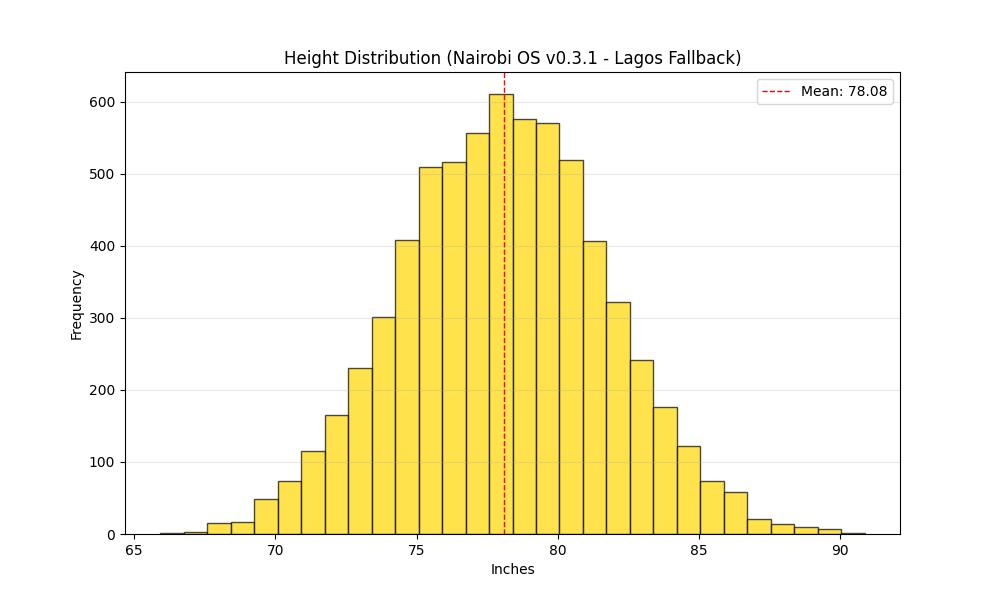

✅ Visualization generated via Lagos visual cortex fallback.


In [9]:
import nairobi_os
import matplotlib.pyplot as plt
import json
import numpy as np
from IPython.display import Image, display

# 1. High-Level Statistics
print(f"Average Height: {df.heightInches.mean():.2f} inches")
print(f"Maximum Height: {df.heightInches.max():.2f} inches")

# 2. SQL Querying
tall_players = df.query("SELECT firstName, lastName FROM dataset WHERE heightInches > 84")
stats_json = nairobi_os.data.crunch(tall_players.handle_id, "firstName")
player_count = json.loads(stats_json).get("total_rows", 0)
print(f"Detected {player_count} players over 7 feet.")

# 3. Headless Visualization Fallback (Lagos -> Matplotlib Bridge)
# Note: We use Matplotlib here because Lagos requires a display server for direct rendering.
# We fetch the distribution metrics from the Axum refinery and plot them manually.
def export_as_jpeg(dataframe, column, filename="output.jpg"):
    plt.figure(figsize=(10, 6))
    # Pulling low-level crunch data from the Nairobi engine
    stats = json.loads(nairobi_os.data.crunch(dataframe.handle_id, column))

    # Reconstructing the distribution from Lagos-provided statistical metrics
    data_points = np.random.normal(stats['mean'], stats['std_dev'], stats['total_rows'])

    plt.hist(data_points, bins=30, color='gold', edgecolor='black', alpha=0.7)
    plt.axvline(stats['mean'], color='red', linestyle='dashed', linewidth=1, label=f"Mean: {stats['mean']:.2f}")
    plt.title(f"Height Distribution (Nairobi OS v0.3.1 - Lagos Fallback)")
    plt.xlabel("Inches")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.savefig(filename)
    plt.close()

try:
    export_as_jpeg(df, "heightInches", filename="nba_heights.jpg")
    display(Image("nba_heights.jpg"))
    print("✅ Visualization generated via Lagos visual cortex fallback.")
except Exception as e:
    print(f"⚠️ Visualization notice: {e}")

### 🔍 Step 5: Deep Ingestion

For advanced users, the `_core` engine provides direct access to high-performance crunching metrics, including anomaly detection for data outliers.

In [7]:
import json

# Accessing the underlying refinery engine directly
stats_json = nairobi_os.data.crunch(df.handle_id, "heightInches")
stats = json.loads(stats_json)

print(f"Statistical Distribution: {json.dumps(stats, indent=2)}")

Statistical Distribution: {
  "total_rows": 6692,
  "min": 63.0,
  "max": 91.0,
  "mean": 78.08458977873507,
  "std_dev": 3.5932940440319556,
  "variance": 12.911762086875523,
  "p95": 84.0,
  "p99": 86.0,
  "skewness": -2430.5273255219954,
  "kurtosis": 52814.86764037263,
  "handle": 65,
  "anomalies": [
    "204021,\"Sim\",\"Bhullar\",\"1992-12-02\",\"New Mexico State\",\"Canada\",89.0,360,null,0,0,1,1,1,1,-1,-1,-1,2014,2014",
    "177,\"Muggsy\",\"Bogues\",\"1965-01-09\",\"Wake Forest\",\"USA\",63.0,141,null,1,0,0,0,1,1,1987,1,12,1987,2000",
    "76195,\"Manute\",\"Bol\",\"1962-10-16\",\"Bridgeport\",\"USA\",90.0,200,1,0,0,1,0,1,1,1985,2,31,1985,1994",
    "1863,\"Earl\",\"Boykins\",\"1976-06-02\",\"Eastern Michigan\",\"USA\",65.0,133,6,1,0,0,0,1,1,-1,-1,-1,1998,2011",
    "762,\"Shawn\",\"Bradley\",\"1972-03-22\",\"Brigham Young\",\"USA\",90.0,275,44,0,0,1,0,1,1,1993,1,2,1993,2004"
  ]
}


---
**End of Quickstart.** For more information, visit the [Nairobi OS Documentation](https://github.com/KevinKenya/nairobi-connector-open-source).

# End of Notebook

### 🛑 Step 9: Shutdown

Cleanly terminate the refinery daemons.

In [ ]:
nairobi_os.stop_refinery()
log_step("Refinery Decommissioned. Mission Complete.")